In [1]:
import keras
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import cv2
import random
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns 
from keras.applications import VGG16
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-04-30 14:08:59.105816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777558139.323952      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777558139.399331      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777558139.900514      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777558139.900560      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777558139.900563      23 computation_placer.cc:177] computation placer alr

In [2]:
# Define the path to the dataset
dataset_path = '/kaggle/input/datasets/plameneduardo/sarscov2-ctscan-dataset'

# Define data augmentation function
def scalar(img):
    return img

# Define data augmentation generators
tr_gen = ImageDataGenerator(preprocessing_function=scalar, horizontal_flip=True)
ts_gen = ImageDataGenerator(preprocessing_function=scalar)

# Function to load and resize the dataset
def load_and_resize_dataset(dataset_path, target_size):
    X = []
    y = []
    labels = {'COVID': 1, 'non-COVID': 0}
    
    for label, code in labels.items():
        label_path = os.path.join(dataset_path, label)
        for image_file in os.listdir(label_path):
            image_path = os.path.join(label_path, image_file)
            image = cv2.imread(image_path)  # Read image in default mode (BGR)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
            image = cv2.resize(image, target_size)  # Resize the image
            X.append(image)
            y.append(code)
    
    return np.array(X), np.array(y)

# Load and resize the dataset
target_size = (224, 224)  # Specify the target size
X, y = load_and_resize_dataset(dataset_path, target_size)

In [3]:
# Splitting the dataset into training and testing sets
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [4]:
# Further splitting the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.2, random_state=42)

In [5]:
# Normalization
X_train = X_train / 255
X_val = X_val / 255
X_test = X_test / 255

# One Hot Encoding
y_train = to_categorical(y_train, 2)
y_val = to_categorical(y_val, 2)
y_test = to_categorical(y_test, 2)

In [6]:
# Define batch size
batch_size = 128

# Create generators for training, validation, and testing data
train_gen = tr_gen.flow(X_train, y_train, batch_size=batch_size)
valid_gen = ts_gen.flow(X_val, y_val, batch_size=batch_size, shuffle=False)
test_gen = ts_gen.flow(X_test, y_test, batch_size=batch_size, shuffle=False)

In [7]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(2, activation='softmax'))

# Freeze the convolutional base
base_model.trainable = False

I0000 00:00:1777558195.767669      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777558195.774094      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model.compile(loss=keras.metrics.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [9]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [10]:
# Training the model with data augmentation
VGGHistory = model.fit(train_gen, epochs=20, validation_split=0.15, verbose=1, validation_data=(valid_gen), callbacks=[early_stopping])

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1777558199.726806      73 service.cc:152] XLA service 0x7d0a24004a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777558199.726868      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777558199.726875      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777558200.304438      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-30 14:10:10.351394: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=1,k3=0} for conv %cudnn-conv-b

14/14 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.4925 - loss: 5.2526 - val_accuracy: 0.5403 - val_loss: 0.6631
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 747ms/step - accuracy: 0.6381 - loss: 0.6305 - val_accuracy: 0.7915 - val_loss: 0.4933
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 746ms/step - accuracy: 0.8063 - loss: 0.4751 - val_accuracy: 0.8436 - val_loss: 0.4035
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 715ms/step - accuracy: 0.8607 - loss: 0.3797 - val_accuracy: 0.8768 - val_loss: 0.3386
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 701ms/step - accuracy: 0.8832 - loss: 0.3256 - val_accuracy: 0.8863 - val_loss: 0.2970
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 694ms/step - accuracy: 0.8956 - loss: 0.2860 - val_accuracy: 0.9028 - val_loss: 0.2624
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 695ms/step - accuracy: 0.9112 - loss: 0.2538 - val_accuracy: 0.9052 - val_loss: 0.2397
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 714ms/step - accuracy: 0.9202 - loss: 0.2208 - val_accuracy: 0.9218 -

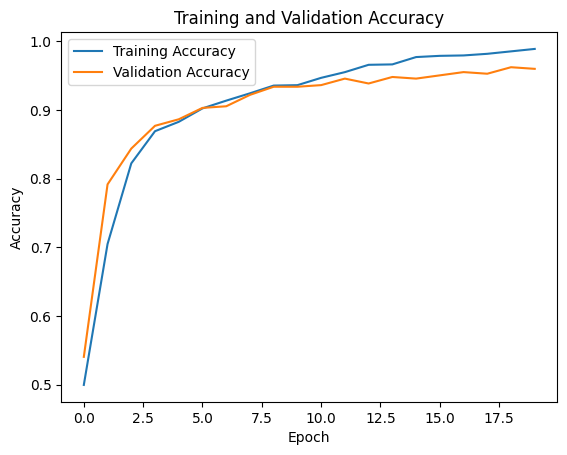

In [11]:
# Plot training & validation accuracy values
plt.plot(VGGHistory.history['accuracy'])
plt.plot(VGGHistory.history['val_accuracy'])
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='upper left')
plt.show()

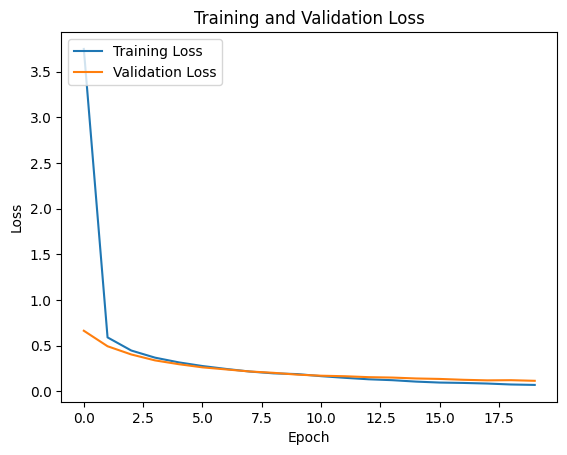

In [12]:
# Plot training & validation loss values
plt.plot(VGGHistory.history['loss'])
plt.plot(VGGHistory.history['val_loss'])
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper left')
plt.show()

In [13]:
# Get the number of steps for each generator
train_steps = len(X_train) // batch_size
valid_steps = len(X_val) // batch_size
test_steps = len(X_test) // batch_size

# Evaluate the model on the training, validation, and test sets
train_score = model.evaluate(train_gen, steps=train_steps)
valid_score = model.evaluate(valid_gen, steps=valid_steps)
test_score = model.evaluate(test_gen, steps=test_steps)

# Print the scores
print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 566ms/step - accuracy: 0.9903 - loss: 0.0680
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 572ms/step - accuracy: 0.9541 - loss: 0.1147
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step - accuracy: 0.9688 - loss: 0.1191
Train Loss:  0.06799617409706116
Train Accuracy:  0.9897836446762085
--------------------
Validation Loss:  0.10788241028785706
Validation Accuracy:  0.9609375
--------------------
Test Loss:  0.12204378843307495
Test Accuracy:  0.96484375


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step

2026-04-30 14:14:52.493323: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=1,k3=0} for conv %cudnn-conv-bias-activation.40 = (f32[117,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[117,64,224,224]{3,2,1,0} %bitcast.504, f32[64,64,3,3]{3,2,1,0} %bitcast.511, f32[64]{0} %bitcast.513), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block1_conv2_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-30 14:14:52.664174: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.170994224s
T

3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 20s/step
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       196
           1       0.96      0.98      0.97       177

    accuracy                           0.97       373
   macro avg       0.97      0.97      0.97       373
weighted avg       0.97      0.97      0.97       373



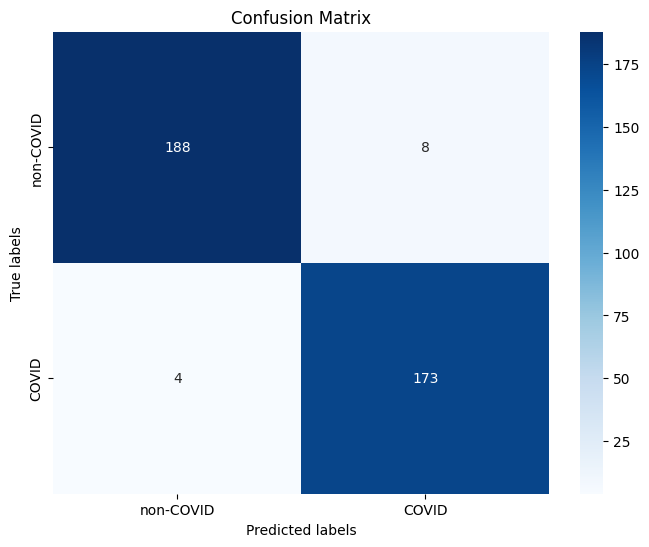

In [14]:
# Predictions on the test data
y_pred = model.predict(test_gen)

# Convert predicted probabilities to class labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert one-hot encoded true labels to class labels
y_true_labels = np.argmax(y_test, axis=1)

# Generate classification report
print(classification_report(y_true_labels, y_pred_labels))

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['non-COVID', 'COVID'], yticklabels=['non-COVID', 'COVID'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [15]:
import os

# 1. Save the best weights
weights_path = 'best_model_weights.weights.h5'
model.save_weights(weights_path)
print(f"Best weights saved to: {weights_path}")

# 2. Save all metrics to a text file
metrics_log_path = 'model_evaluation_metrics.txt'
with open(metrics_log_path, 'w') as f:
    f.write("MODEL EVALUATION RESULTS\n")
    f.write("="*25 + "\n\n")
    
    f.write("Final Training Metrics (Last Epoch):\n")
    f.write(f"Train Loss: {VGGHistory.history['loss'][-1]:.4f}\n")
    f.write(f"Train Accuracy: {VGGHistory.history['accuracy'][-1]:.4f}\n")
    f.write(f"Val Loss: {VGGHistory.history['val_loss'][-1]:.4f}\n")
    f.write(f"Val Accuracy: {VGGHistory.history['val_accuracy'][-1]:.4f}\n\n")
    
    f.write("Evaluated Scores on Test Set:\n")
    f.write(f"Test Loss: {test_score[0]:.4f}\n")
    f.write(f"Test Accuracy: {test_score[1]:.4f}\n\n")
    
    f.write("Detailed Classification Report:\n")
    f.write(classification_report(y_true_labels, y_pred_labels))

print(f"Metrics log saved to: {metrics_log_path}")

# 3. Save the Accuracy Graph
plt.figure(figsize=(10, 6))
plt.plot(VGGHistory.history['accuracy'], label='Training Accuracy')
plt.plot(VGGHistory.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.savefig('accuracy_graph.png')
plt.close()

# 4. Save the Loss Graph
plt.figure(figsize=(10, 6))
plt.plot(VGGHistory.history['loss'], label='Training Loss')
plt.plot(VGGHistory.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.savefig('loss_graph.png')
plt.close()

# 5. Save the Confusion Matrix Plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['non-COVID', 'COVID'], 
            yticklabels=['non-COVID', 'COVID'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.close()

print("All evaluation graphs (Accuracy, Loss, Confusion Matrix) have been saved as .png files.")

Best weights saved to: best_model_weights.weights.h5
Metrics log saved to: model_evaluation_metrics.txt
All evaluation graphs (Accuracy, Loss, Confusion Matrix) have been saved as .png files.


In [16]:
import os
import zipfile

def zip_directory(directory_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(directory_path):
            for file in files:
                # Avoid zipping the zip file itself if it's created in the same directory
                if file != output_path:
                    zipf.write(os.path.join(root, file), 
                               os.path.relpath(os.path.join(root, file), 
                               os.path.join(directory_path, '..')))

# Define paths for Kaggle output
working_dir = '/kaggle/working/'
zip_name = 'dl_project_output.zip'

# Execute zipping
zip_directory(working_dir, zip_name)

print(f"Success! All files in {working_dir} have been zipped into {zip_name}")

Success! All files in /kaggle/working/ have been zipped into dl_project_output.zip
